# Time Series Decomposition

## Purpose

Having established that the climate anomaly series is non-stationary and becomes stationary after first differencing, the next step is to investigate the underlying structure of the time series.

Time series decomposition separates the observed series into three fundamental components:

- **Trend:** Long-term changes in global temperature anomalies over time.
- **Seasonality:** Repeating patterns that occur at regular intervals.
- **Residual (Irregular Component):** Random fluctuations not explained by trend or seasonality.

By decomposing the series, we can better understand the drivers of climate variability and determine the relative importance of long-term warming trends, recurring seasonal behavior, and unexplained variation.

### Objectives

- Extract and visualize trend, seasonal, and residual components.
- Examine the magnitude and stability of long-term climate trends.
- Identify recurring seasonal patterns.
- Assess the level of unexplained variability in the series.
- Generate insights that support subsequent forecasting and predictive modeling.

### Expected Outcome

A clearer understanding of the structural components governing global temperature anomalies, providing a foundation for advanced time series forecasting models.

In [1]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv("/content/monthly_csv.csv")

df["Date"] = pd.to_datetime(df["Date"])

climate = (
    df.groupby("Date")["Mean"]
      .mean()
      .reset_index()
)

climate = climate.sort_values("Date")

climate.set_index(
    "Date",
    inplace=True
)

Perform Decomposition


In [4]:
decomposition = seasonal_decompose(
    climate["Mean"],
    model="additive",
    period=12
)

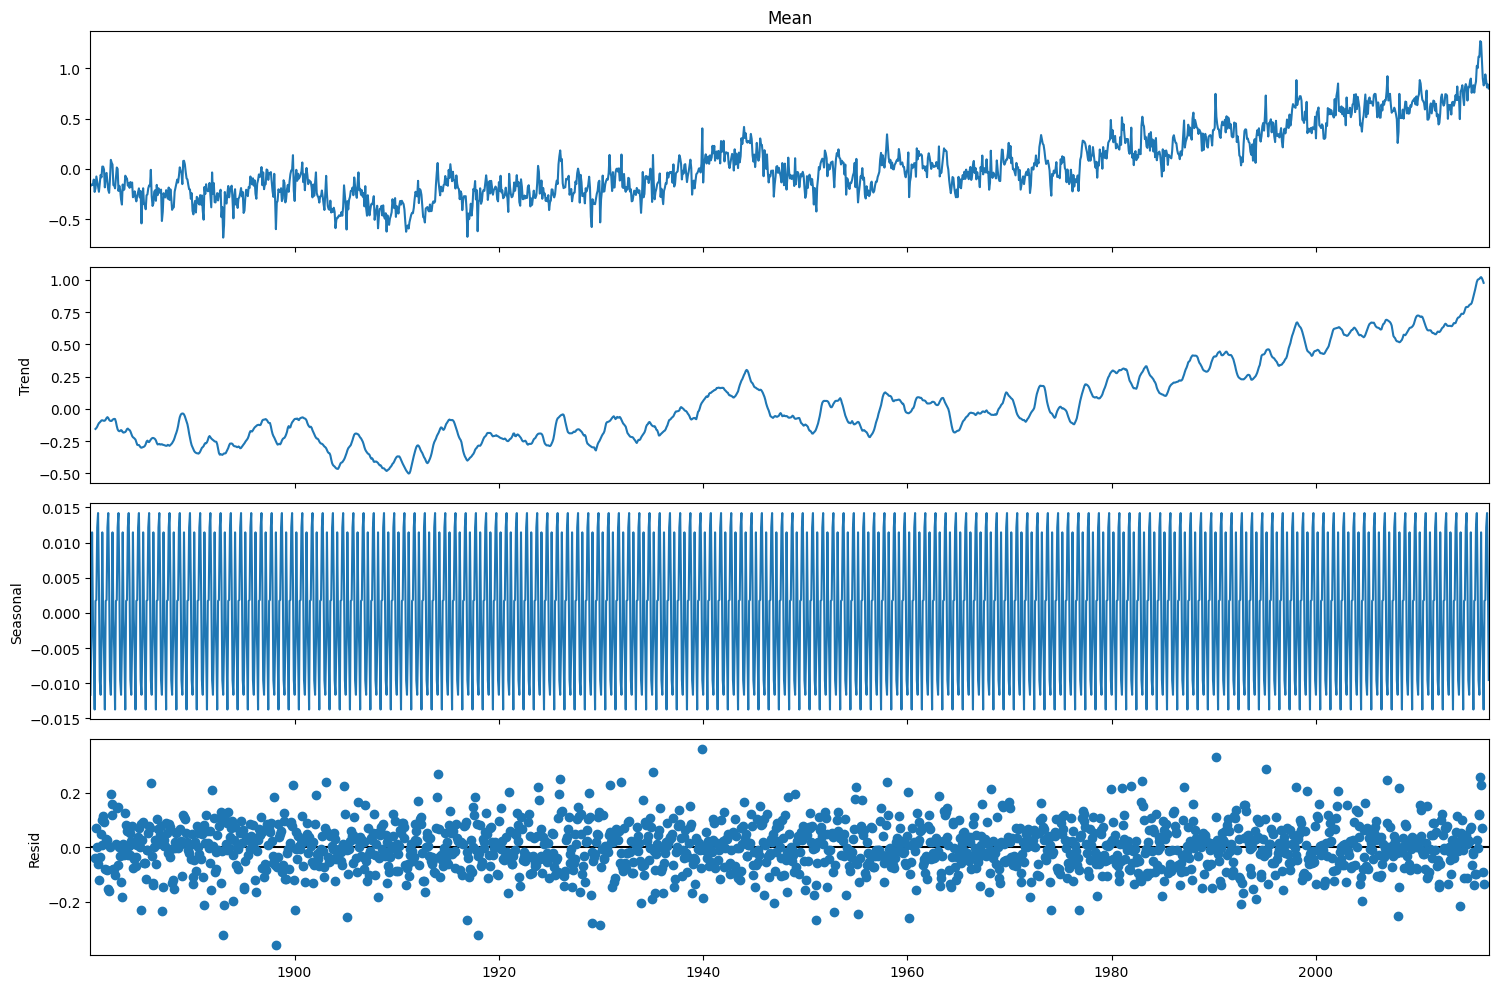

In [5]:
fig = decomposition.plot()

fig.set_size_inches(
    15,
    10
)

plt.tight_layout()

plt.savefig(
    "time_series_decomposition.png",
    dpi=300
)

plt.show()

Extract Components


In [6]:
trend = decomposition.trend

seasonal = decomposition.seasonal

residual = decomposition.resid

Trend Component


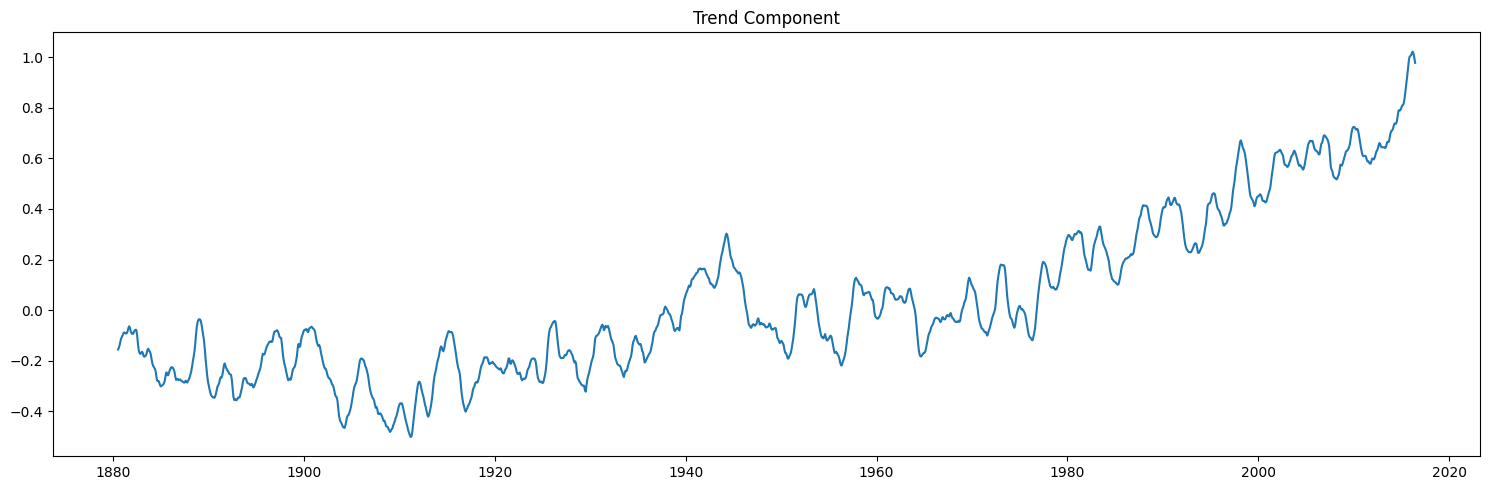

In [7]:

plt.figure(figsize=(15,5))

plt.plot(
    trend
)

plt.title(
    "Trend Component"
)

plt.tight_layout()

plt.savefig(
    "trend_component.png",
    dpi=300
)

plt.show()

Seasonal Component


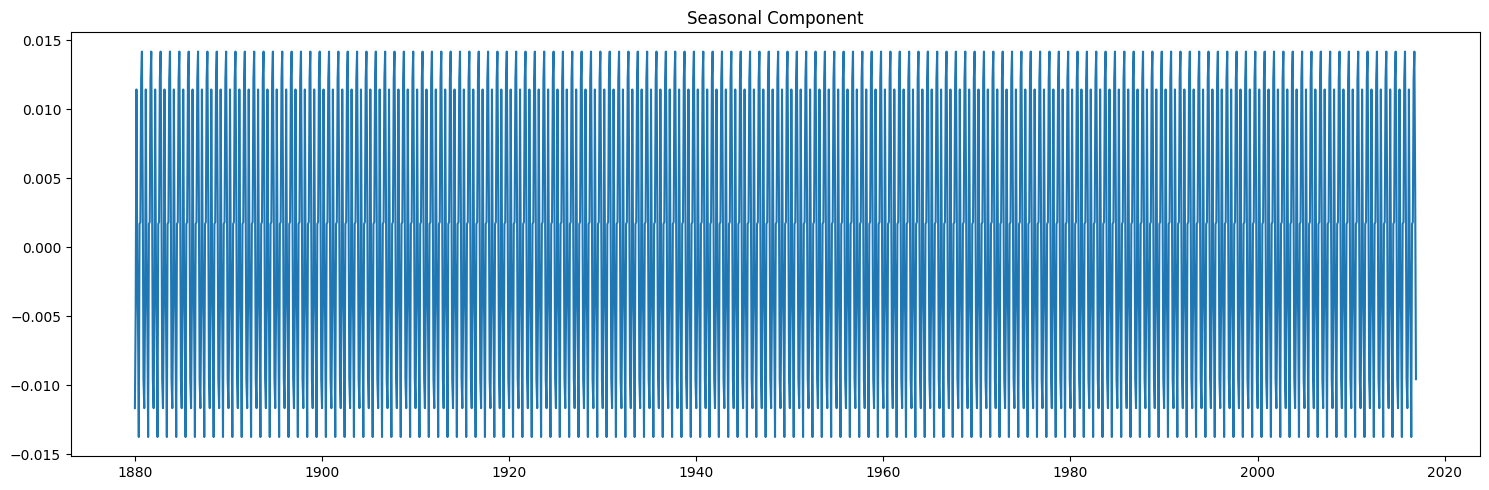

In [8]:
plt.figure(figsize=(15,5))

plt.plot(
    seasonal
)

plt.title(
    "Seasonal Component"
)

plt.tight_layout()

plt.savefig(
    "seasonal_component.png",
    dpi=300
)

plt.show()

Residual Component



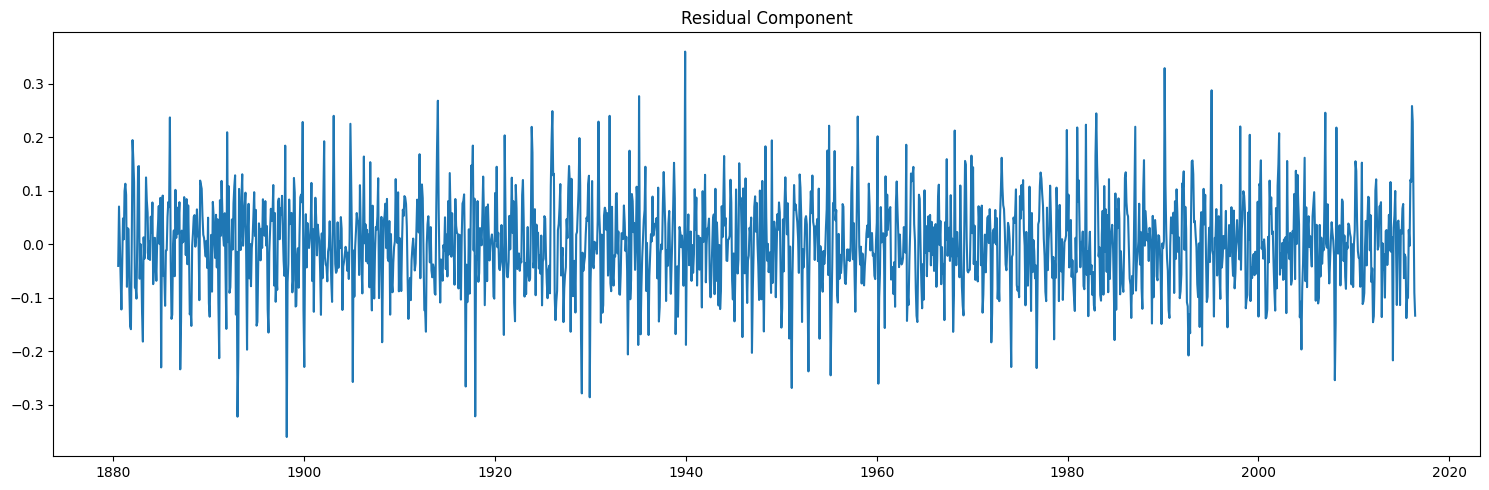

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    residual
)

plt.title(
    "Residual Component"
)

plt.tight_layout()

plt.savefig(
    "residual_component.png",
    dpi=300
)

plt.show()

Summary Statistics


In [11]:
trend.describe()
seasonal.describe()
residual.describe()

,resid
count,1632.000000
mean,0.000139
std,0.086286
min,-0.360375
25%,-0.054707
50%,0.000462
75%,0.052682
max,0.360194
